<a href="https://colab.research.google.com/github/samuelrosendo/DT-WIN-FV-UFAL/blob/main/AN%C3%81LISE_DE_DADOS_JAN_2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#CONECTAR AO GOOGLE DRIVE

In [ ]:
from google.colab import drive #importando dados do google drive
drive.mount('/content/drive') #caminho para acessar até os arquivos do google drive

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import pandas as pd

# Caminho da pasta com os arquivos.dat
pasta = r"/content/drive/MyDrive/Colab Notebooks/PIBIC - SAMUEL ROSENDO/JAN -2025/janeiro - Copia"

# Cria uma lista com todos os arquivos .dat dentro da pasta
arquivos = [
    os.path.join(pasta, arquivo)
    for arquivo in os.listdir(pasta)
    if arquivo.endswith('.dat') and os.path.isfile(os.path.join(pasta, arquivo))
]

# Cria um DataFrame vazio para acumular os dados
tabela_final = pd.DataFrame()

# Percorre cada arquivo encontrado e junta todos os dados
for arquivo in arquivos:
    df = pd.read_csv(arquivo, sep=',', header=1)
    tabela_final = pd.concat([tabela_final, df])

# Remove aspas dos nomes das colunas
tabela_final.columns = tabela_final.columns.str.replace('"', '')

# Converte a coluna de data/hora e ordena os dados
tabela_final['TMSTAMP'] = pd.to_datetime(tabela_final['TMSTAMP'])
tabela_final = tabela_final.sort_values(by='TMSTAMP').reset_index(drop=True)

tabela_final = tabela_final.set_index('TMSTAMP')

# Remove a coluna 'RECNBR'
tabela_final = tabela_final.drop('RECNBR', axis=1, )

# Create a new DataFrame by dropping the specified columns
colunas_para_remover = ["P_FV_Avg", "Q_FV_Avg", "S_FV_Avg", "FP_FV_Avg", "Corrente_FV_Avg", "Tensao_Rede_Avg", "Demanda_Avg"]
tabela_final_sem_colunas = tabela_final.drop(columns=colunas_para_remover)

# Display the first few rows of the new DataFrame to verify the removal
display(tabela_final_sem_colunas.head())

,Radiacao_Avg,Temp_Cel_Avg,Temp_Amb_Avg,Tensao_S1_Avg,Corrente_S1_Avg,Potencia_S1_Avg,Tensao_S2_Avg,Corrente_S2_Avg,Potencia_S2_Avg,Potencia_S1_S2_Avg
TMSTAMP,,,,,,,,,,
2025-01-01 15:02:00,490.3,37.13,32.43,257.6,5.025,1294.0,290.8,4.562,1327.0,2621.0
2025-01-01 15:03:00,265.0,37.17,32.48,252.5,2.671,671.1,285.5,2.397,686.5,1358.0
2025-01-01 15:04:00,134.8,36.60,32.36,248.4,1.255,311.7,275.5,1.154,318.0,629.6
2025-01-01 15:05:00,135.0,36.28,32.29,248.6,1.261,313.4,278.3,1.148,319.7,633.0
2025-01-01 15:06:00,115.0,35.87,32.23,239.9,1.077,258.4,274.3,0.965,264.6,523.0


#JUNTANDO TODOS OS DADOS DE JANEIRO E ORGANIZANDO EM UM DATAFRAME

In [ ]:
import os
import pandas as pd

# Caminho da pasta com os arquivos.dat
pasta = r"/content/drive/MyDrive/Colab Notebooks/PIBIC - SAMUEL ROSENDO/JAN -2025/janeiro - Copia"

# Cria uma lista com todos os arquivos .dat dentro da pasta
arquivos = [
    os.path.join(pasta, arquivo)
    for arquivo in os.listdir(pasta)
    if arquivo.endswith('.dat') and os.path.isfile(os.path.join(pasta, arquivo))
]

# Cria um DataFrame vazio para acumular os dados
tabela_final = pd.DataFrame()

# Percorre cada arquivo encontrado e junta todos os dados
for arquivo in arquivos:
    df = pd.read_csv(arquivo, sep=',', header=1)
    tabela_final = pd.concat([tabela_final, df])

# Remove aspas dos nomes das colunas
tabela_final.columns = tabela_final.columns.str.replace('"', '')

# Converte a coluna de data/hora e ordena os dados
tabela_final['TMSTAMP'] = pd.to_datetime(tabela_final['TMSTAMP'])
tabela_final = tabela_final.sort_values(by='TMSTAMP').reset_index(drop=True)

tabela_final = tabela_final.set_index('TMSTAMP')

tabela_final

,RECNBR,Radiacao_Avg,Temp_Cel_Avg,Temp_Amb_Avg,Tensao_S1_Avg,Corrente_S1_Avg,Potencia_S1_Avg,Tensao_S2_Avg,Corrente_S2_Avg,Potencia_S2_Avg,Potencia_S1_S2_Avg,P_FV_Avg,Q_FV_Avg,S_FV_Avg,FP_FV_Avg,Corrente_FV_Avg,Tensao_Rede_Avg,Demanda_Avg
TMSTAMP,,,,,,,,,,,,,,,,,,
2025-01-01 15:02:00,1010724,490.3,37.13,32.43,257.6,5.025,1294.0,290.8,4.562,1327.0,2621.0,2441.0,76.70,2445.0,0.998,11.490,228.1,447.4
2025-01-01 15:03:00,1010725,265.0,37.17,32.48,252.5,2.671,671.1,285.5,2.397,686.5,1358.0,1244.0,26.29,1247.0,0.997,6.318,223.0,443.6
2025-01-01 15:04:00,1010726,134.8,36.60,32.36,248.4,1.255,311.7,275.5,1.154,318.0,629.6,526.4,100.70,536.1,0.982,3.514,219.3,439.2
2025-01-01 15:05:00,1010727,135.0,36.28,32.29,248.6,1.261,313.4,278.3,1.148,319.7,633.0,529.3,99.20,538.8,0.982,3.517,218.5,438.5
2025-01-01 15:06:00,1010728,115.0,35.87,32.23,239.9,1.077,258.4,274.3,0.965,264.6,523.0,426.8,118.00,443.0,0.963,3.176,216.7,436.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-01-31 23:55:00,1054457,0.0,29.01,28.31,0.0,0.000,0.0,0.0,0.000,0.0,0.0,0.0,0.00,0.0,-7999.000,0.000,210.9,1390.0
2025-01-31 23:56:00,1054458,0.0,29.03,28.30,0.0,0.000,0.0,0.0,0.000,0.0,0.0,0.0,0.00,0.0,-7999.000,0.000,211.0,1334.0
2025-01-31 23:57:00,1054459,0.0,29.07,28.31,0.0,0.000,0.0,0.0,0.000,0.0,0.0,0.0,0.00,0.0,-7999.000,0.000,211.4,1258.0


#DESCRIÇÃO DO DATAFRAME - JAN/2025


In [ ]:
tabela_final.describe()

,RECNBR,Radiacao_Avg,Temp_Cel_Avg,Temp_Amb_Avg,Tensao_S1_Avg,Corrente_S1_Avg,Potencia_S1_Avg,Tensao_S2_Avg,Corrente_S2_Avg,Potencia_S2_Avg,Potencia_S1_S2_Avg,P_FV_Avg,Q_FV_Avg,S_FV_Avg,FP_FV_Avg,Corrente_FV_Avg,Tensao_Rede_Avg,Demanda_Avg
count,4.373800e+04,43738.000000,43738.000000,43738.000000,43738.000000,43738.000000,43738.000000,43738.000000,43738.000000,43738.000000,43738.000000,43738.000000,43738.000000,43738.000000,43738.000000,43738.000000,43738.000000,43738.000000
mean,1.032592e+06,241.263704,32.767758,29.359741,133.234214,2.249394,562.639569,150.359950,2.123726,596.646276,1159.286908,1050.033482,4.672030,1083.052041,-3559.019094,-20.304776,218.232830,581.102496
std,1.262622e+04,327.918865,6.027828,2.385649,125.747522,3.008091,744.452269,141.199979,2.886818,801.227526,1545.295105,1416.981104,321.557199,1430.309745,3975.679259,452.183515,5.946107,533.024295
min,1.010724e+06,0.000000,25.280000,23.980000,-0.142000,0.000000,-0.012000,0.000000,0.000000,0.000000,0.000000,0.000000,-1531.000000,0.000000,-7999.000000,-7999.000000,196.200000,26.660000
25%,1.021658e+06,0.000000,28.410000,27.700000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-30.830000,0.000000,-7999.000000,0.000000,213.700000,213.500000
50%,1.032592e+06,15.120000,29.560000,28.630000,238.500000,0.166500,27.195000,267.700000,0.111000,26.155000,53.005000,4.976500,0.000000,201.600000,0.028000,2.386500,217.300000,346.500000
75%,1.043527e+06,457.300000,37.350000,31.260000,254.400000,4.462000,1148.000000,285.100000,4.173750,1204.000000,2352.000000,2143.000000,10.425000,2187.000000,0.993000,10.470000,222.300000,1002.750000
max,1.054461e+06,1280.000000,51.540000,35.820000,319.400000,11.000000,2601.000000,356.400000,10.800000,2846.000000,5447.000000,4831.000000,1749.000000,4903.000000,1.000000,22.020000,236.700000,4093.000000


## REMOÇÃO DA COLUNA "RECNBR"

In [ ]:
# Remove a coluna 'RECNBR'
tabela_final = tabela_final.drop('RECNBR', axis=1, )

# Exibe as primeiras linhas do DataFrame para verificar a remoção
display(tabela_final.head())

,Radiacao_Avg,Temp_Cel_Avg,Temp_Amb_Avg,Tensao_S1_Avg,Corrente_S1_Avg,Potencia_S1_Avg,Tensao_S2_Avg,Corrente_S2_Avg,Potencia_S2_Avg,Potencia_S1_S2_Avg,P_FV_Avg,Q_FV_Avg,S_FV_Avg,FP_FV_Avg,Corrente_FV_Avg,Tensao_Rede_Avg,Demanda_Avg
TMSTAMP,,,,,,,,,,,,,,,,,
2025-01-01 15:02:00,490.3,37.13,32.43,257.6,5.025,1294.0,290.8,4.562,1327.0,2621.0,2441.0,76.70,2445.0,0.998,11.490,228.1,447.4
2025-01-01 15:03:00,265.0,37.17,32.48,252.5,2.671,671.1,285.5,2.397,686.5,1358.0,1244.0,26.29,1247.0,0.997,6.318,223.0,443.6
2025-01-01 15:04:00,134.8,36.60,32.36,248.4,1.255,311.7,275.5,1.154,318.0,629.6,526.4,100.70,536.1,0.982,3.514,219.3,439.2
2025-01-01 15:05:00,135.0,36.28,32.29,248.6,1.261,313.4,278.3,1.148,319.7,633.0,529.3,99.20,538.8,0.982,3.517,218.5,438.5
2025-01-01 15:06:00,115.0,35.87,32.23,239.9,1.077,258.4,274.3,0.965,264.6,523.0,426.8,118.00,443.0,0.963,3.176,216.7,436.2


# VIZUALIZAÇÃO DOS DADOS

## IDENTIFICAR O NUMERO DE COLUNA E A FORMATAÇÃO DOS DADOS




**Reasoning**:
Inspect the data types of the columns in `tabela_final` to identify numerical columns.



In [ ]:
tabela_final.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 43738 entries, 2025-01-01 15:02:00 to 2025-01-31 23:59:00
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Radiacao_Avg        43738 non-null  float64
 1   Temp_Cel_Avg        43738 non-null  float64
 2   Temp_Amb_Avg        43738 non-null  float64
 3   Tensao_S1_Avg       43738 non-null  float64
 4   Corrente_S1_Avg     43738 non-null  float64
 5   Potencia_S1_Avg     43738 non-null  float64
 6   Tensao_S2_Avg       43738 non-null  float64
 7   Corrente_S2_Avg     43738 non-null  float64
 8   Potencia_S2_Avg     43738 non-null  float64
 9   Potencia_S1_S2_Avg  43738 non-null  float64
 10  P_FV_Avg            43738 non-null  float64
 11  Q_FV_Avg            43738 non-null  float64
 12  S_FV_Avg            43738 non-null  float64
 13  FP_FV_Avg           43738 non-null  float64
 14  Corrente_FV_Avg     43738 non-null  float64
 15  Tensao_Rede_Avg   

**Reasoning**:
All columns are of float64 dtype, which are numerical and suitable for plotting. Create a list of these column names.



In [ ]:
num_colunas = tabela_final.columns.tolist()
print(num_colunas)

['Radiacao_Avg', 'Temp_Cel_Avg', 'Temp_Amb_Avg', 'Tensao_S1_Avg', 'Corrente_S1_Avg', 'Potencia_S1_Avg', 'Tensao_S2_Avg', 'Corrente_S2_Avg', 'Potencia_S2_Avg', 'Potencia_S1_S2_Avg', 'P_FV_Avg', 'Q_FV_Avg', 'S_FV_Avg', 'FP_FV_Avg', 'Corrente_FV_Avg', 'Tensao_Rede_Avg', 'Demanda_Avg']


## ITERAÇÃO E PLOTAGEM DOS GRÁFICOS

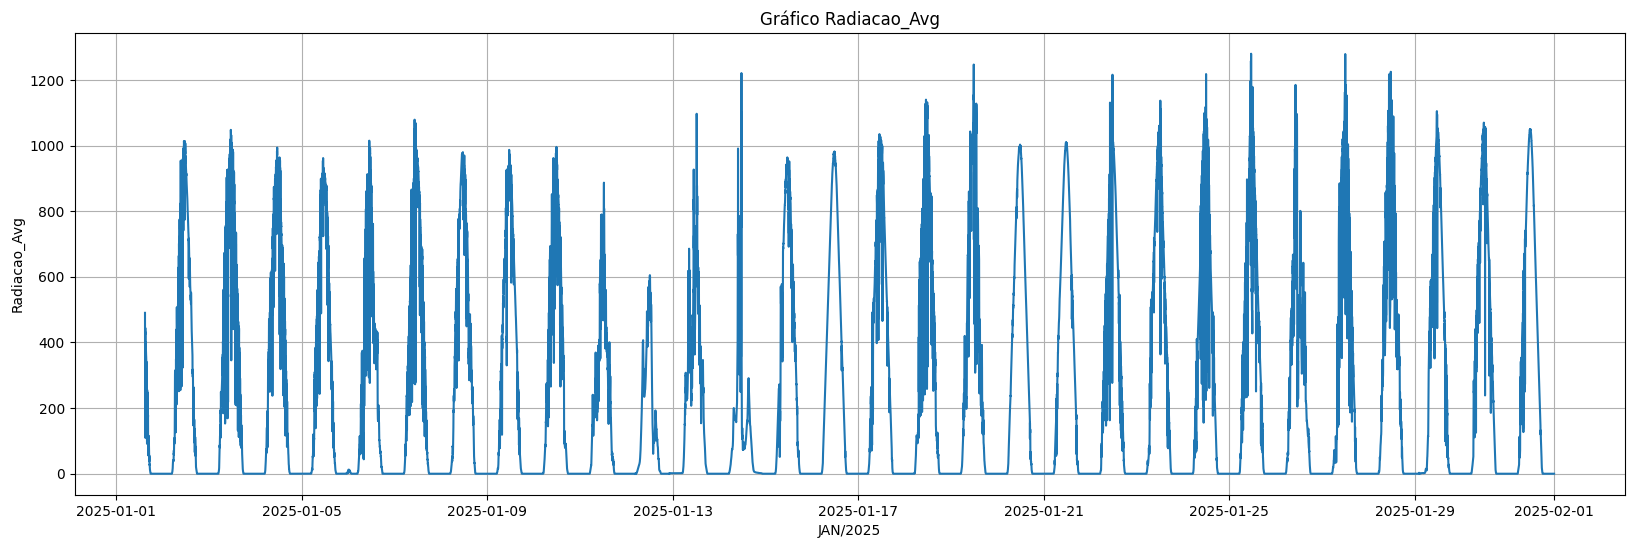

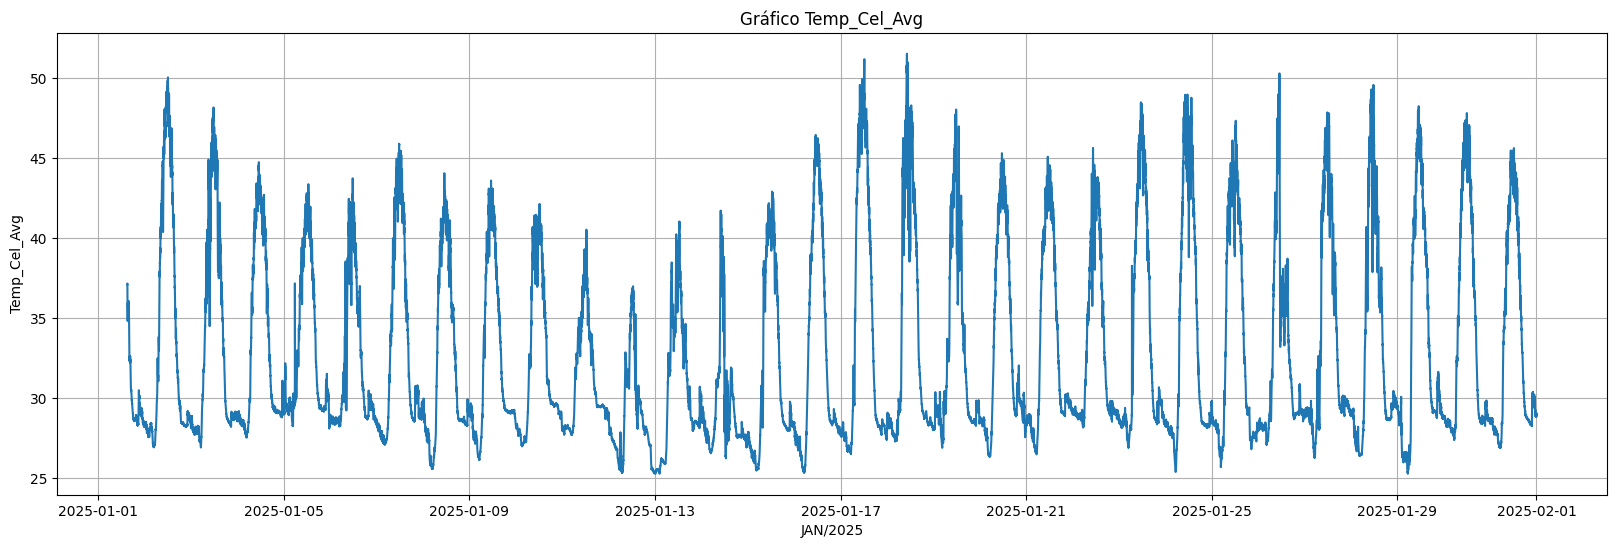

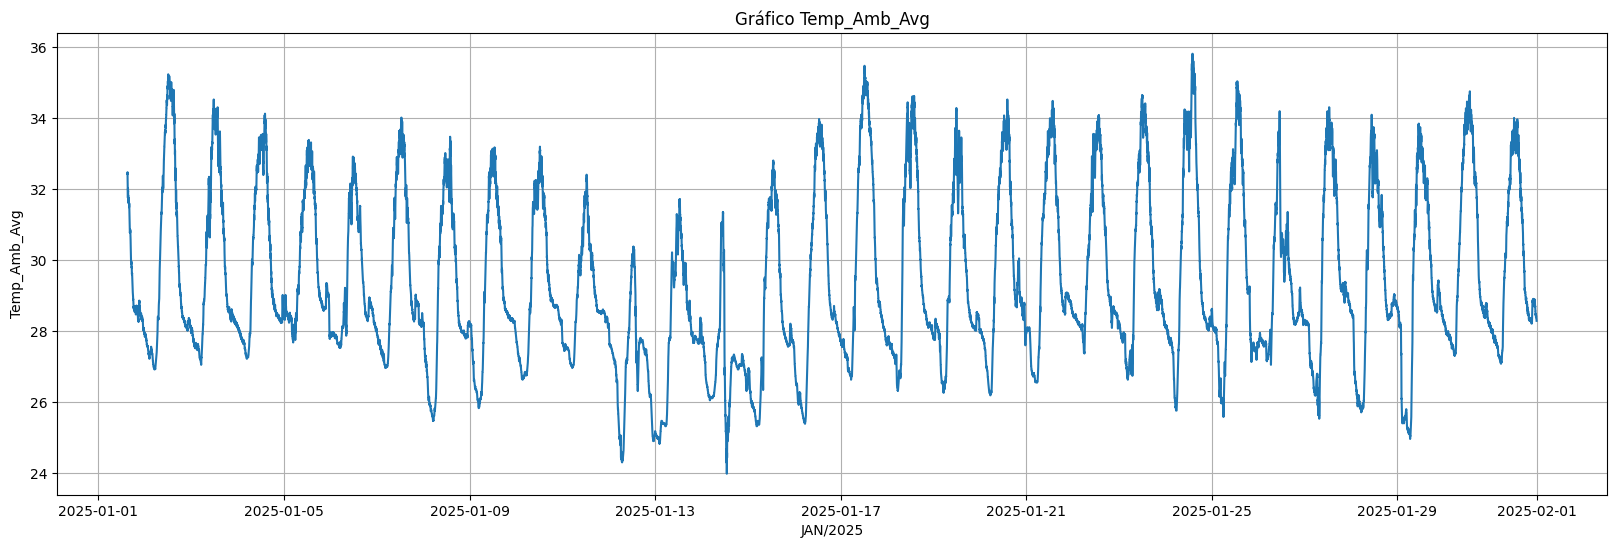

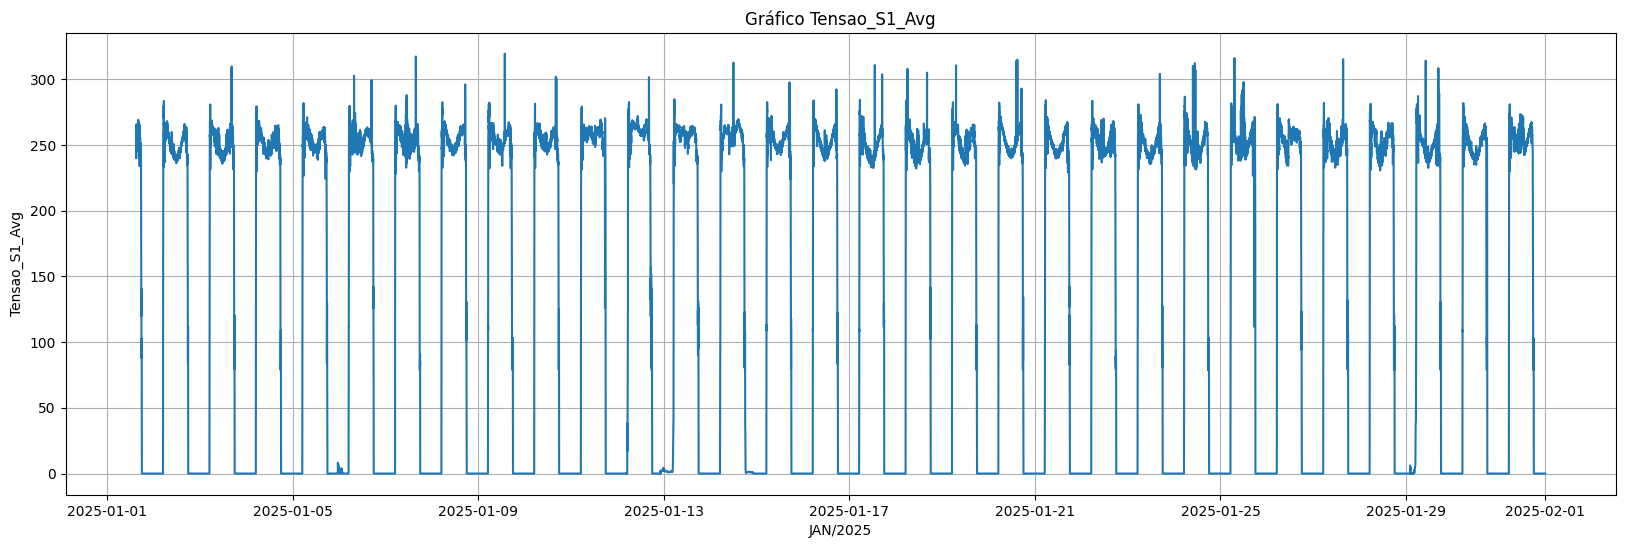

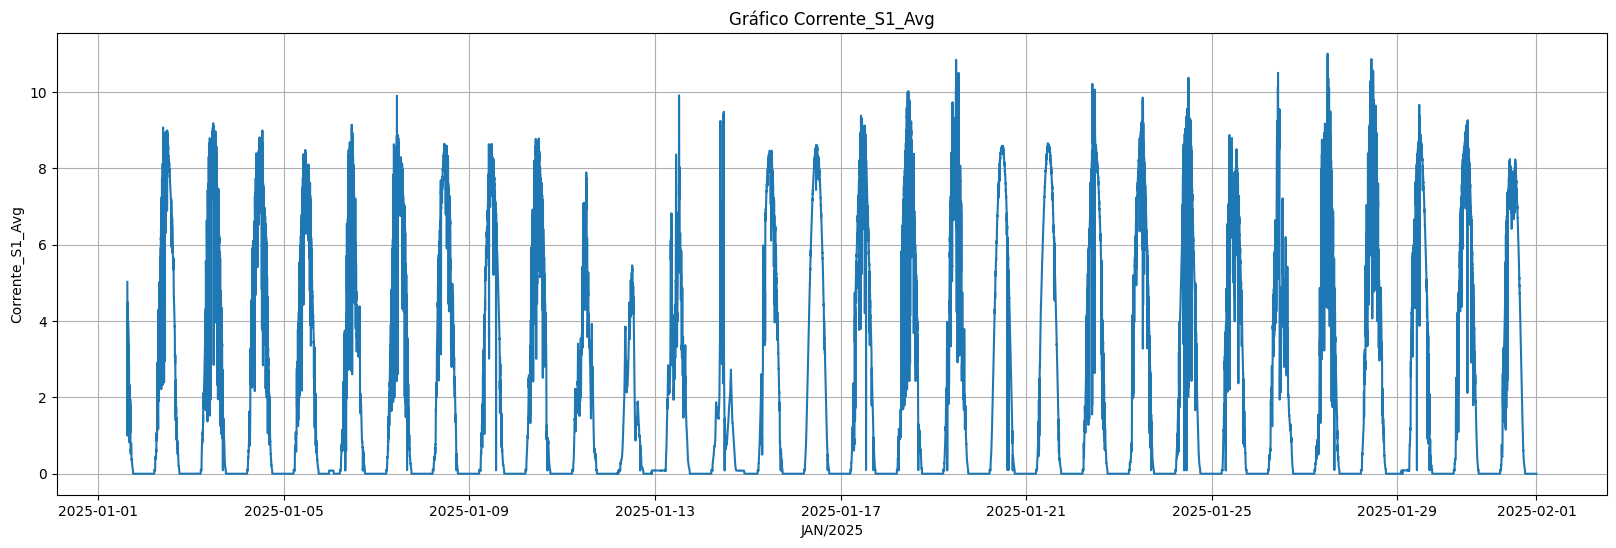

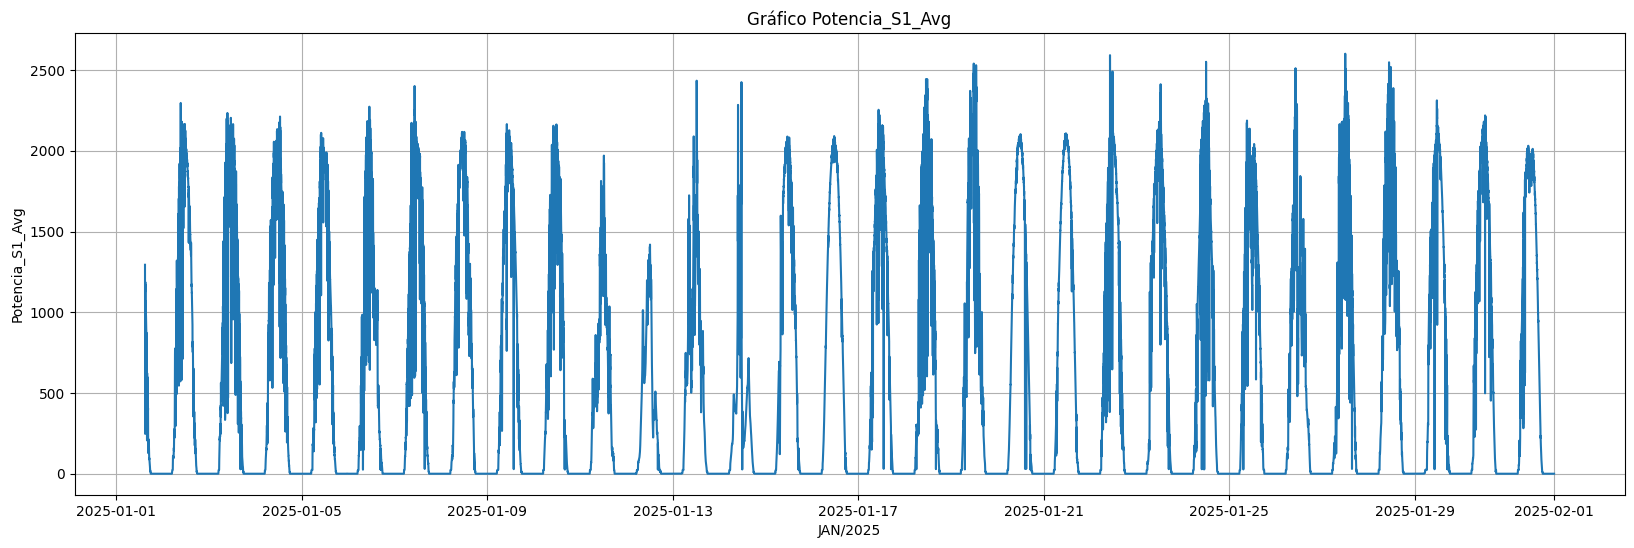

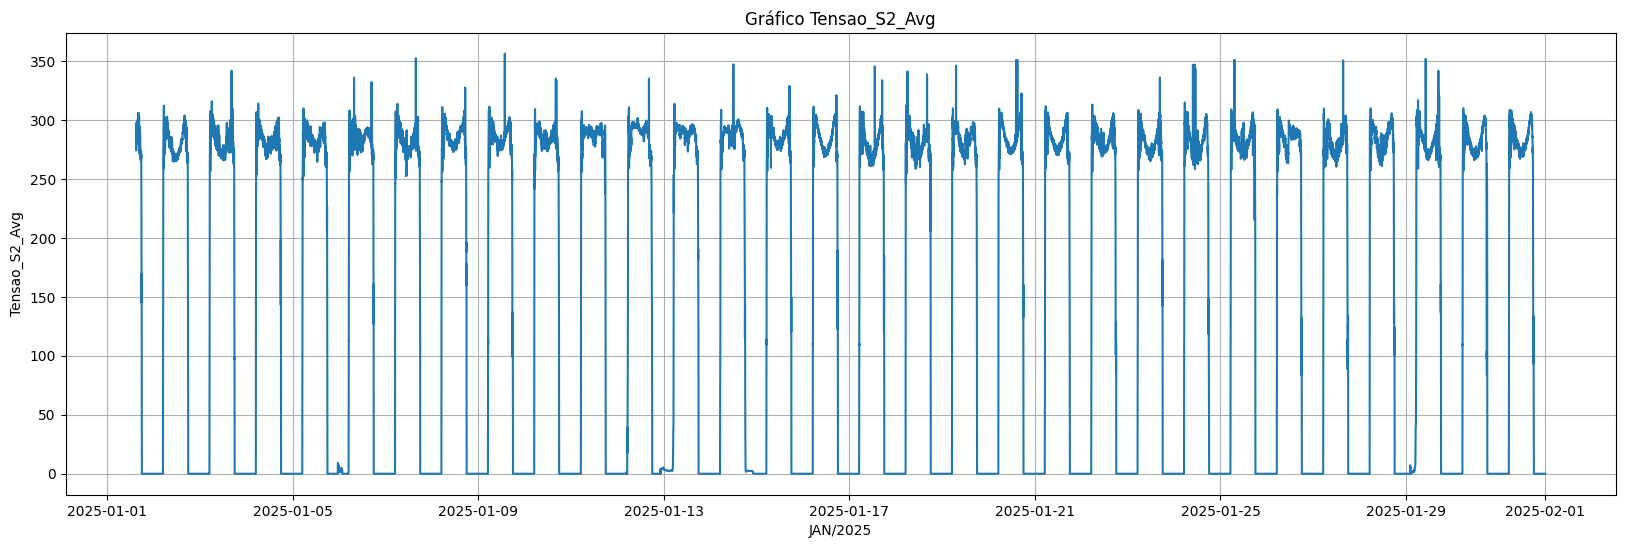

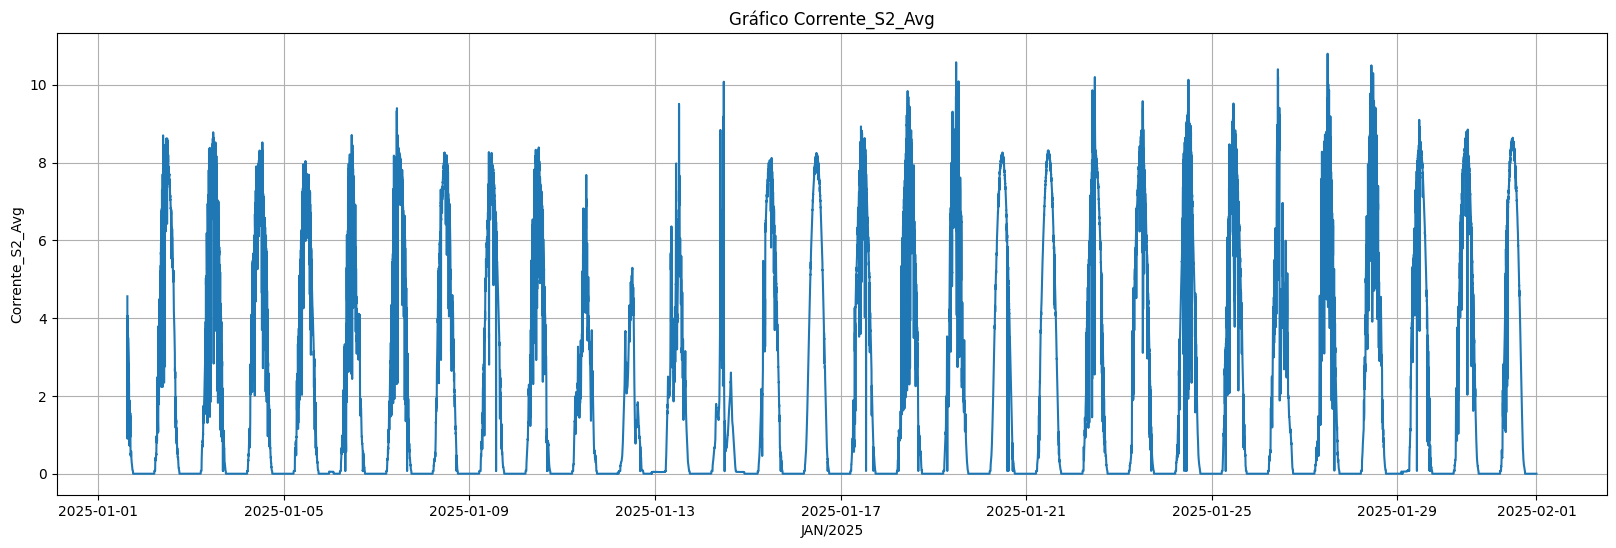

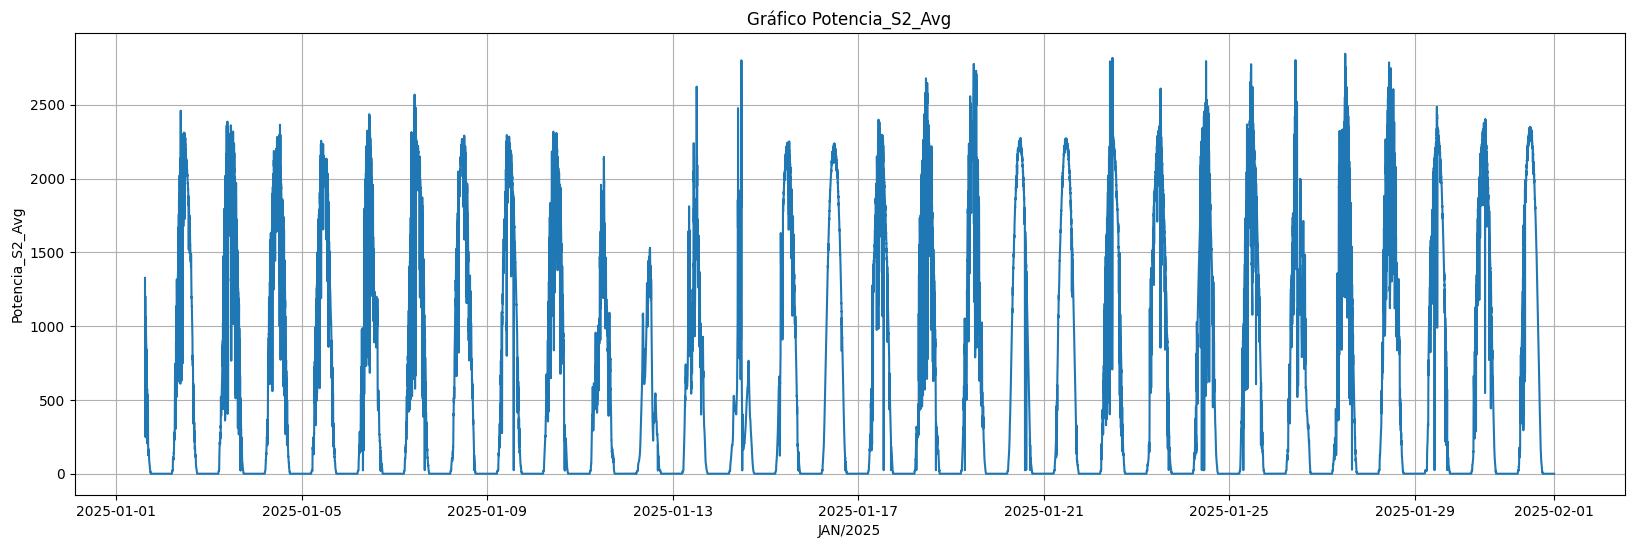

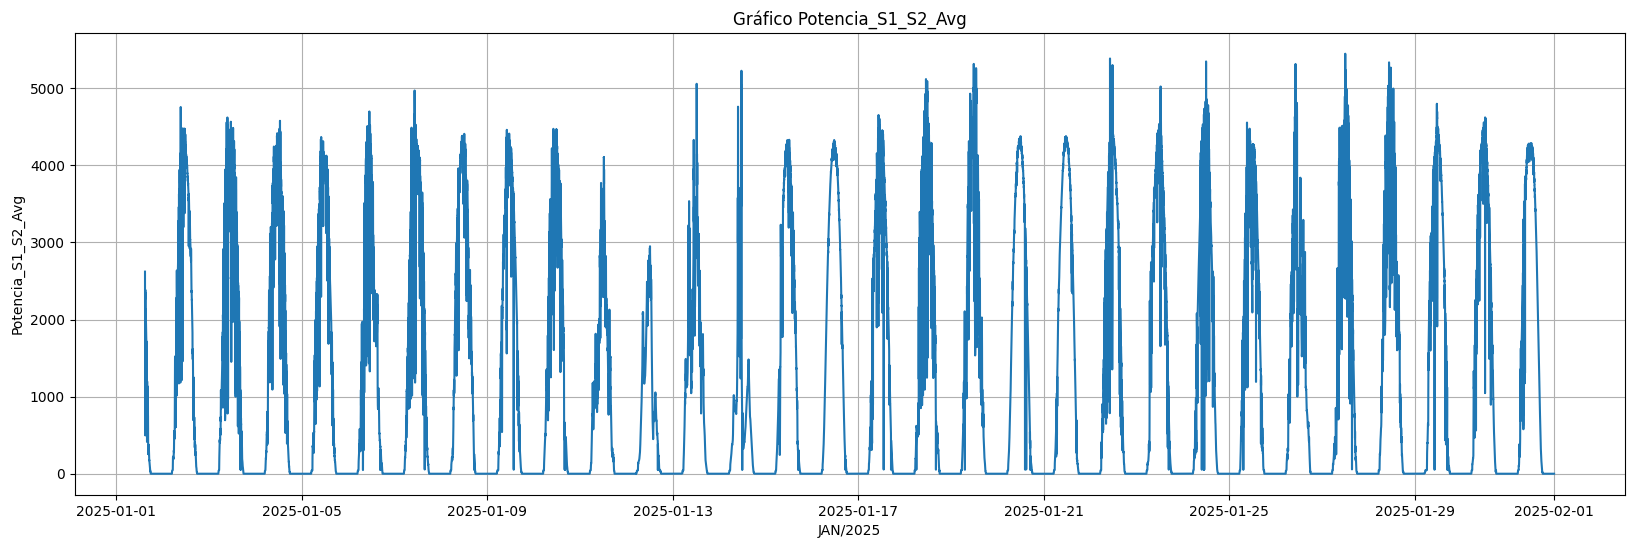

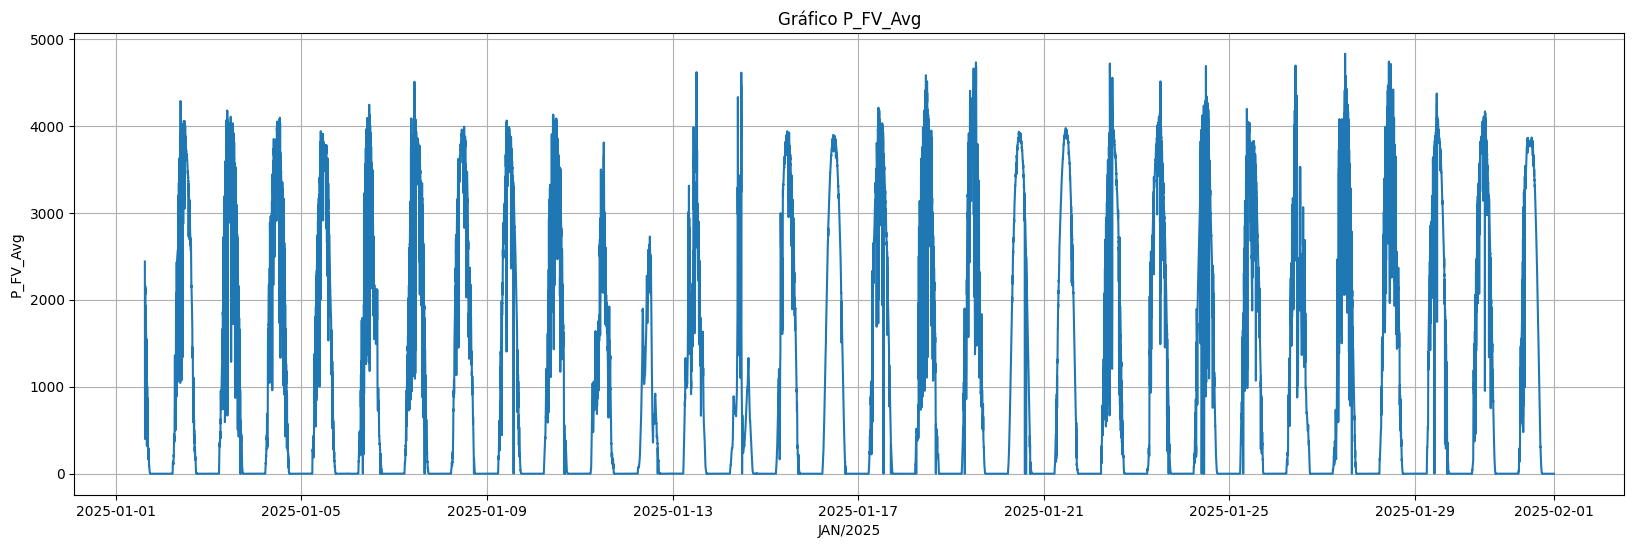

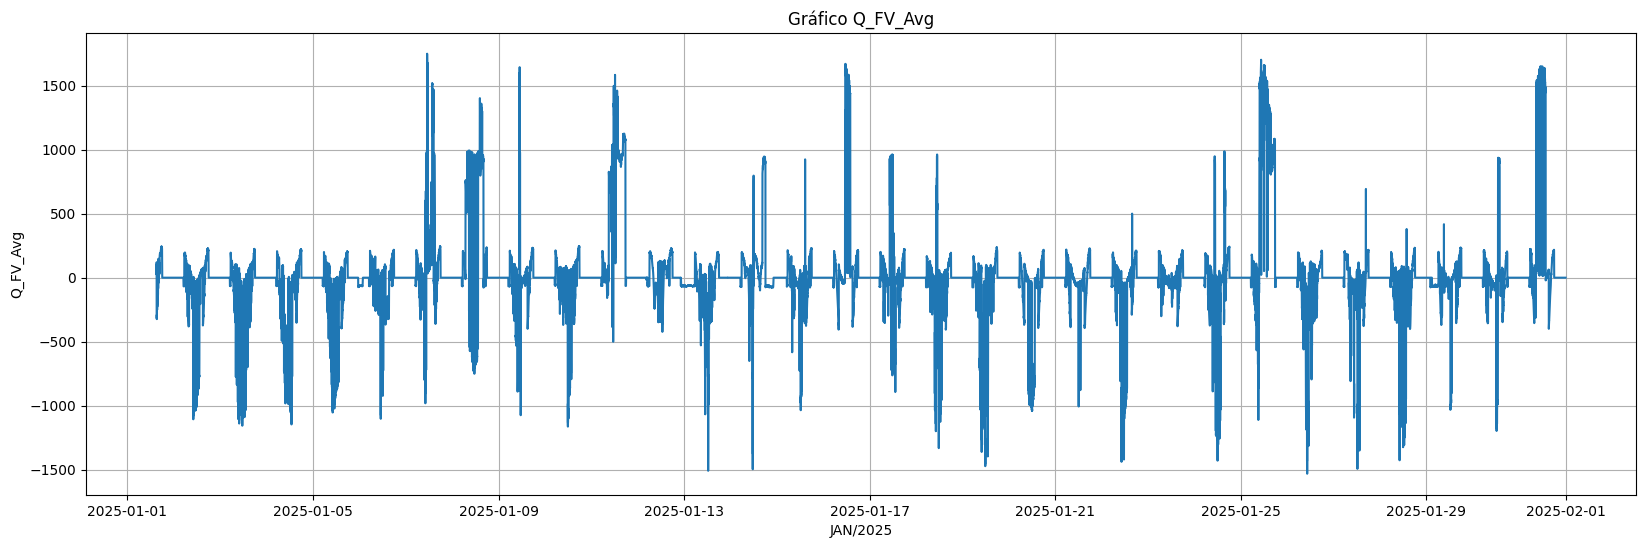

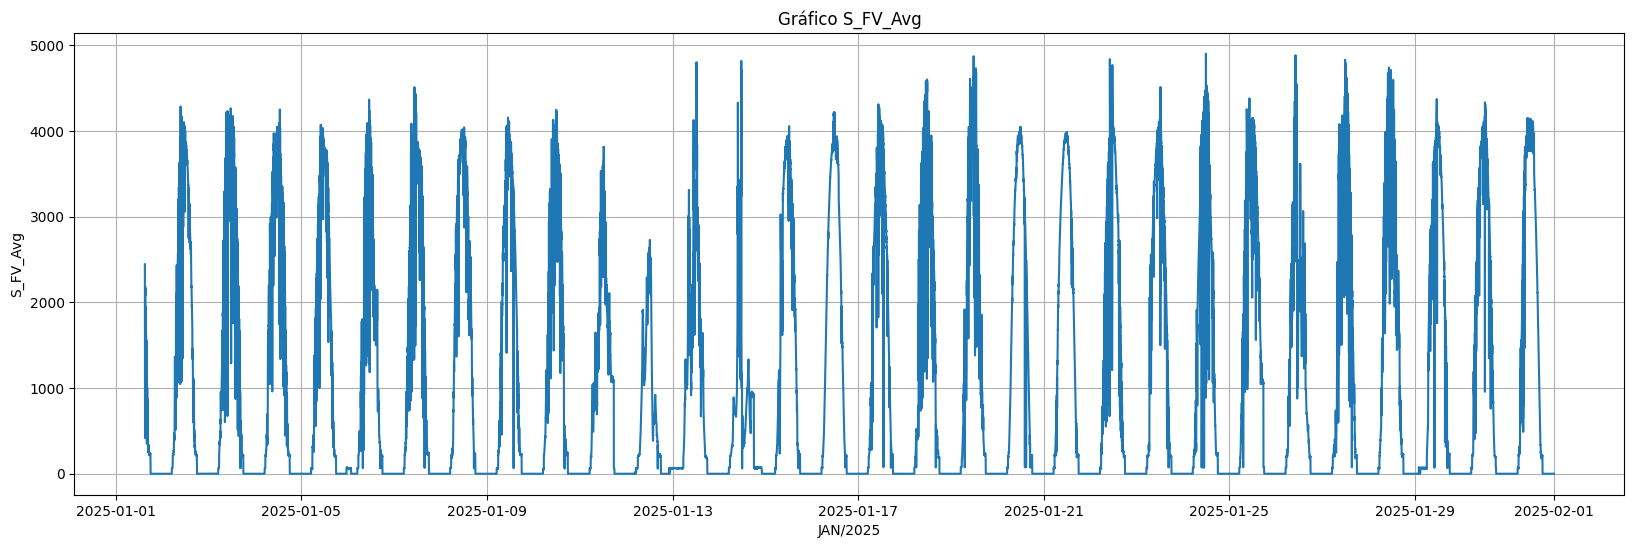

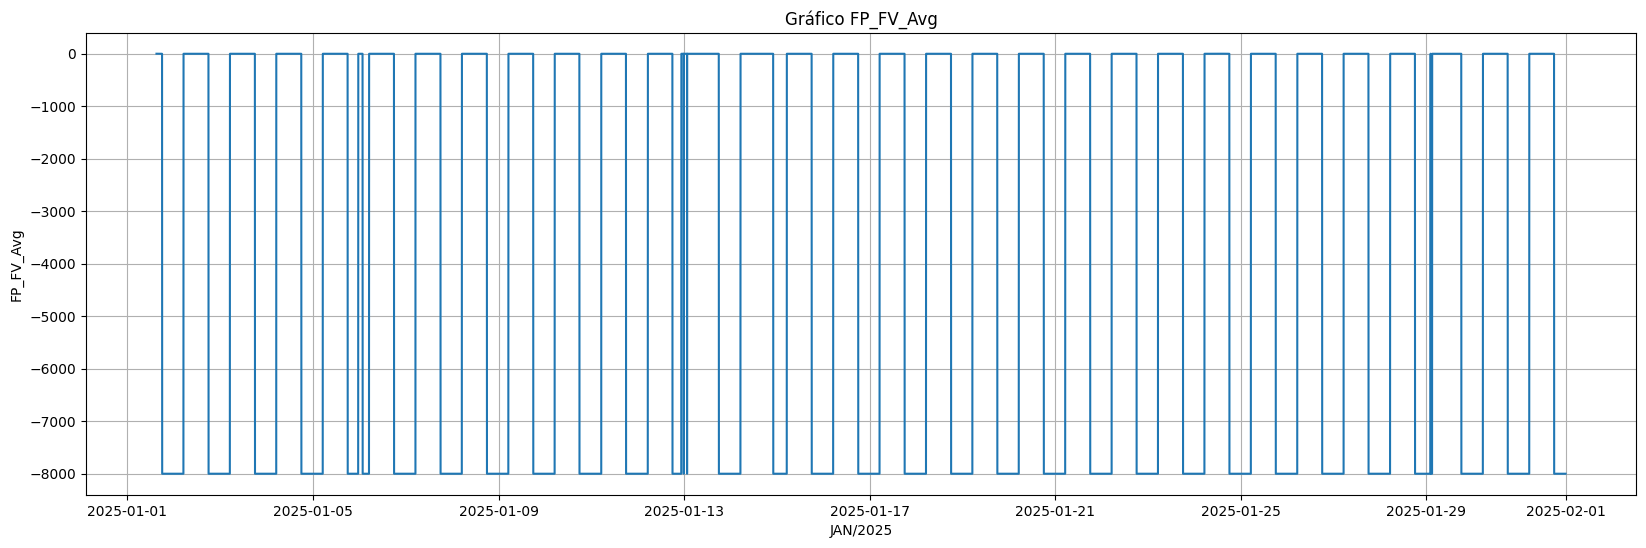

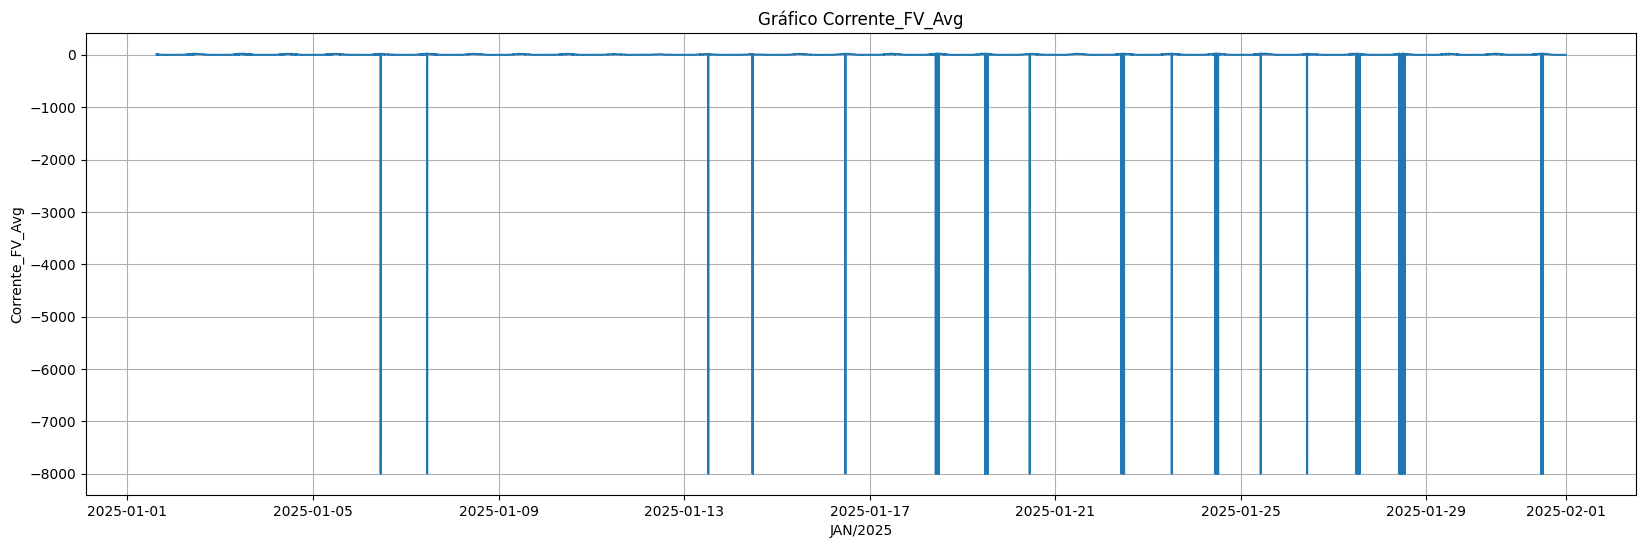

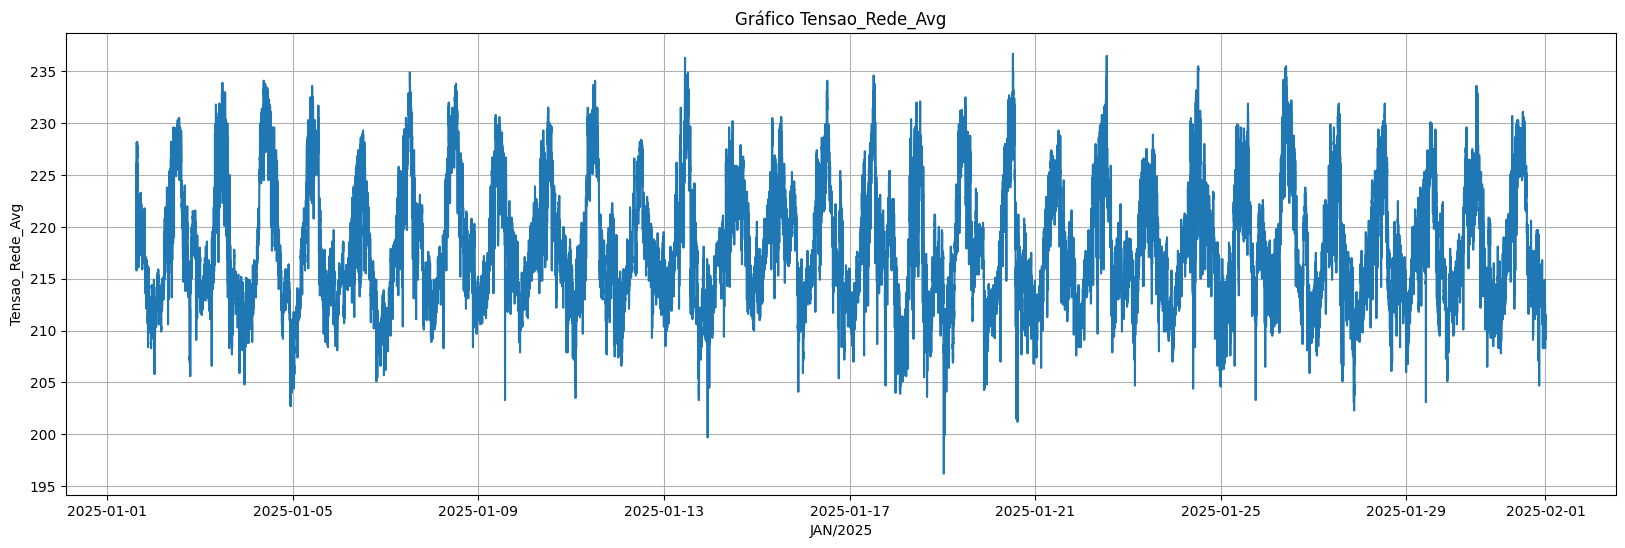

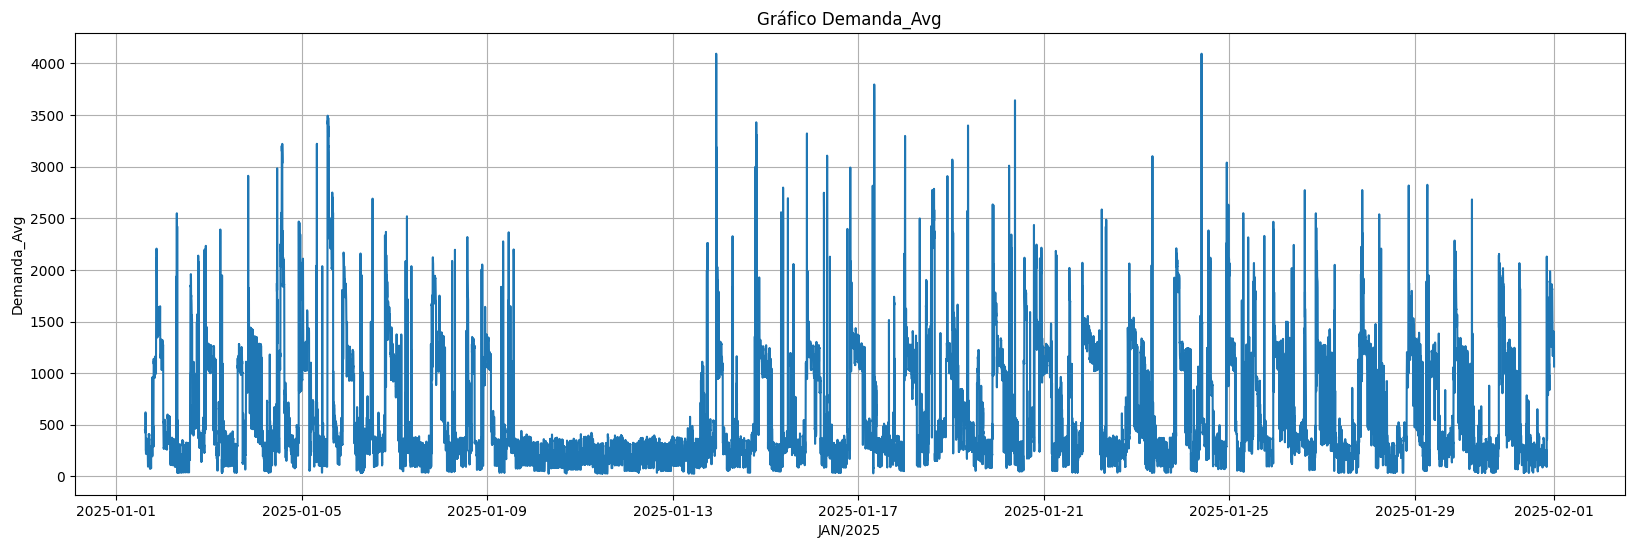

In [ ]:
import matplotlib.pyplot as plt

# Iterar por cada coluna numérica e criar um gráfico
for col in num_colunas:
    plt.figure(figsize=(20, 6)) # Ajuste padrão
    plt.plot(tabela_final.index, tabela_final[col])
    plt.title(f'Gráfico {col}')
    plt.xlabel('JAN/2025')
    plt.ylabel(col)
    plt.grid(True)
    plt.show()

## REMOÇÃO DE ALGUMAS COLUNAS DO DATAFRAME


In [ ]:

colunas_para_remover = ["P_FV_Avg", "Q_FV_Avg", "S_FV_Avg", "FP_FV_Avg", "Corrente_FV_Avg", "Tensao_Rede_Avg", "Demanda_Avg"]
tabela_final_sem_colunas = tabela_final.drop(columns=colunas_para_remover)

display(tabela_final_sem_colunas.head())

,Radiacao_Avg,Temp_Cel_Avg,Temp_Amb_Avg,Tensao_S1_Avg,Corrente_S1_Avg,Potencia_S1_Avg,Tensao_S2_Avg,Corrente_S2_Avg,Potencia_S2_Avg,Potencia_S1_S2_Avg
TMSTAMP,,,,,,,,,,
2025-01-01 15:02:00,490.3,37.13,32.43,257.6,5.025,1294.0,290.8,4.562,1327.0,2621.0
2025-01-01 15:03:00,265.0,37.17,32.48,252.5,2.671,671.1,285.5,2.397,686.5,1358.0
2025-01-01 15:04:00,134.8,36.60,32.36,248.4,1.255,311.7,275.5,1.154,318.0,629.6
2025-01-01 15:05:00,135.0,36.28,32.29,248.6,1.261,313.4,278.3,1.148,319.7,633.0
2025-01-01 15:06:00,115.0,35.87,32.23,239.9,1.077,258.4,274.3,0.965,264.6,523.0
